## Introduction

Clustering is an unsupervised machine learning technique used to group similar data points together. Unlike supervised learning, clustering does not rely on labelled data.

K-Means clustering is one of the most widely used clustering algorithms. It partitions data into *k* clusters by minimising the distance between data points and their respective cluster centroids.

In this tutorial, we apply K-Means to a credit card dataset to discover distinct customer segments.

## Import Libraries


We begin by importing the necessary libraries for data processing, visualisation, and clustering.

In [13]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## Load Dataset

The dataset contains customer credit card usage information, including:
- Balance
- Purchases
- Credit limit
- Payment behaviour

These features will be used to identify patterns in customer activity.

In [14]:
df = pd.read_csv("Credit Card.csv")

if 'CUST_ID' in df.columns:
    df = df.drop('CUST_ID', axis=1)

df = df.select_dtypes(include=['float64', 'int64'])
df = df.fillna(df.mean())

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Correlation Analysis

A correlation heatmap is used to identify relationships between features. Highly correlated features may indicate similar behavioural patterns.

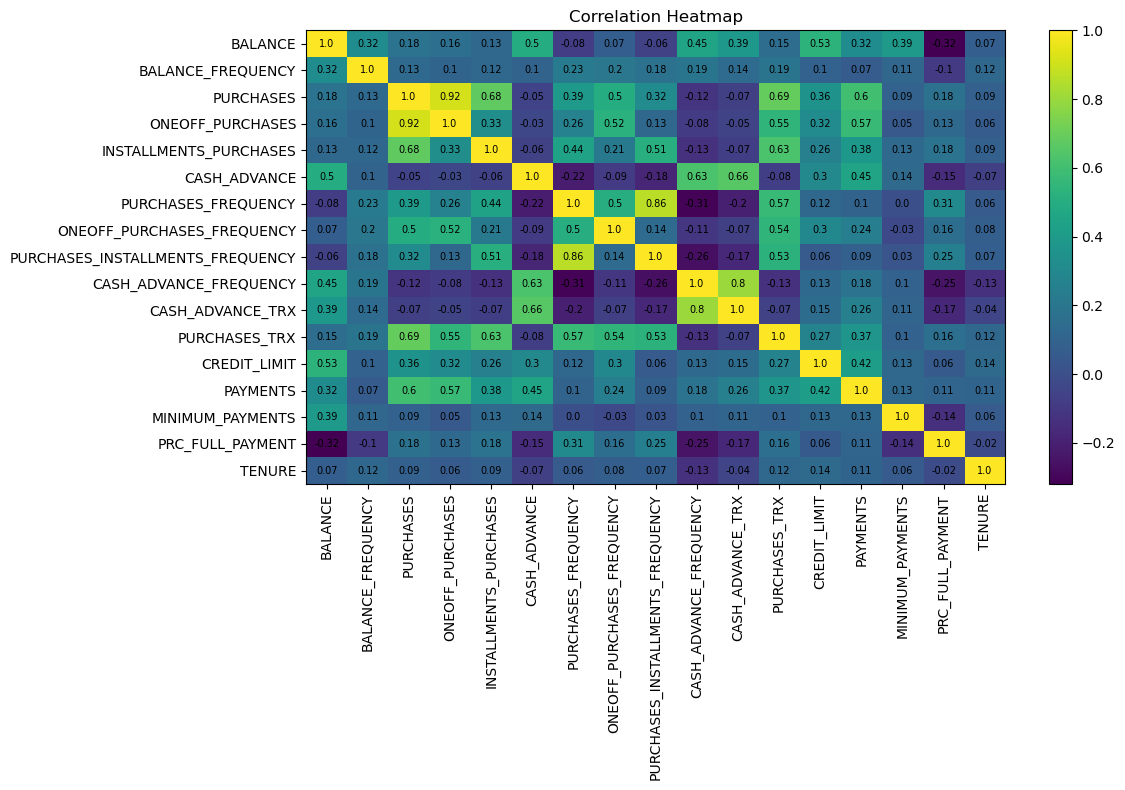

In [15]:
corr = df.corr()

plt.figure(figsize=(12, 8))
heatmap = plt.imshow(corr, aspect='auto')
plt.colorbar(heatmap)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha='center', va='center', fontsize=7)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Data Preprocessing

Feature scaling is essential for K-Means because the algorithm is distance-based. Standardisation ensures that all features contribute equally.

In [16]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

## Elbow Method

Determining the Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of clusters by plotting inertia against the number of clusters.

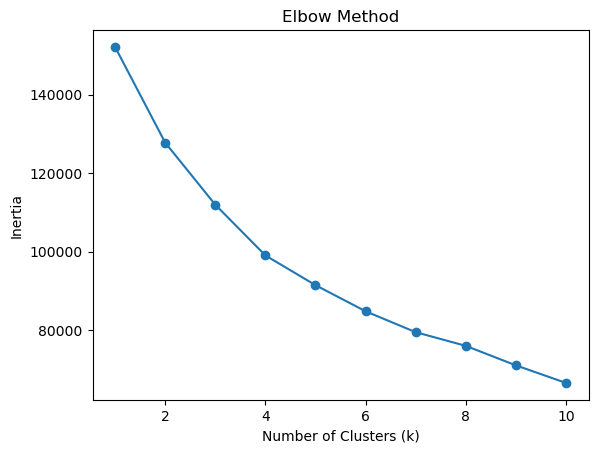

In [17]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## Silhouette Score

The silhouette score evaluates how well-separated the clusters are. Higher values indicate better clustering performance.

In [18]:
sil_scores = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    sil_scores.append(silhouette_score(scaled_data, labels))

print("Silhouette scores:", sil_scores)

Silhouette scores: [np.float64(0.21003302619400505), np.float64(0.25055570796307736), np.float64(0.1976074492720698), np.float64(0.1931688590154638)]


## K-Means Clustering

Based on the evaluation methods, we select k = 3 clusters.

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

## Cluster Distribution

This plot shows how many customers belong to each cluster.

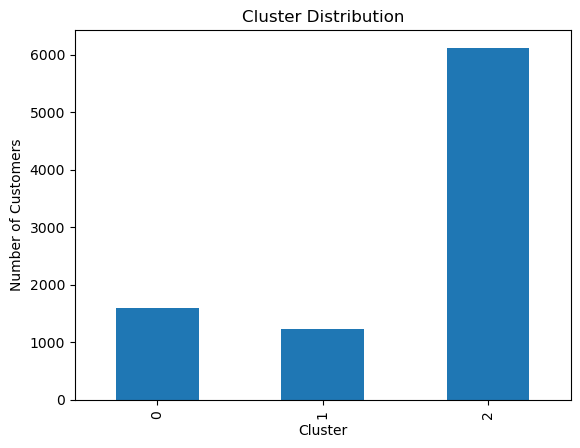

In [20]:
plt.figure()
df['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Cluster Distribution")
plt.show()

## PCA Visualisation

Principal Component Analysis (PCA) is used to reduce dimensionality and visualise clusters in two dimensions.

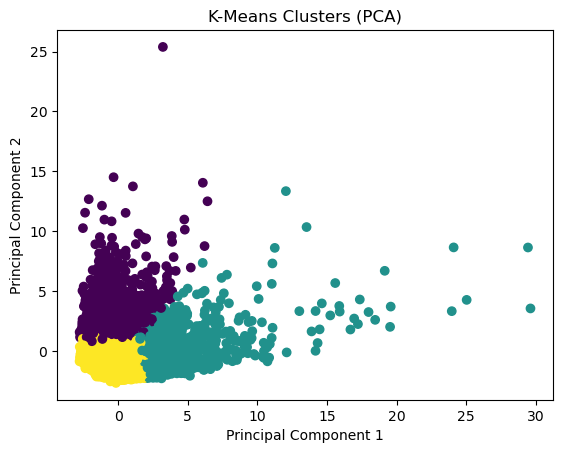

In [21]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure()
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA)")
plt.show()

## Cluster Interpretation Plots

 Cluster Analysis

Boxplots help compare feature distributions across clusters.

<Figure size 640x480 with 0 Axes>

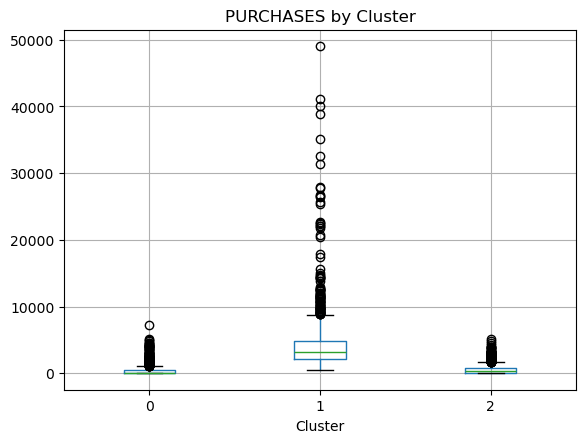

<Figure size 640x480 with 0 Axes>

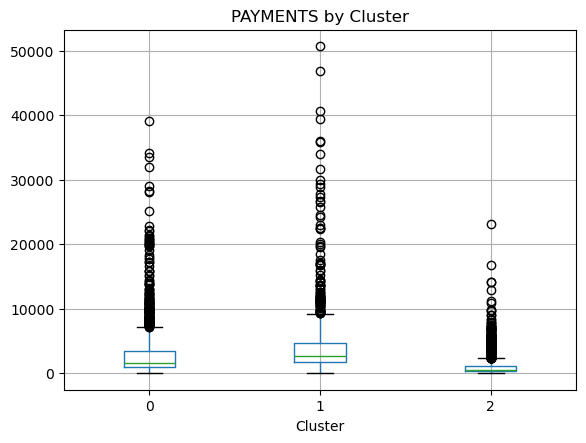

<Figure size 640x480 with 0 Axes>

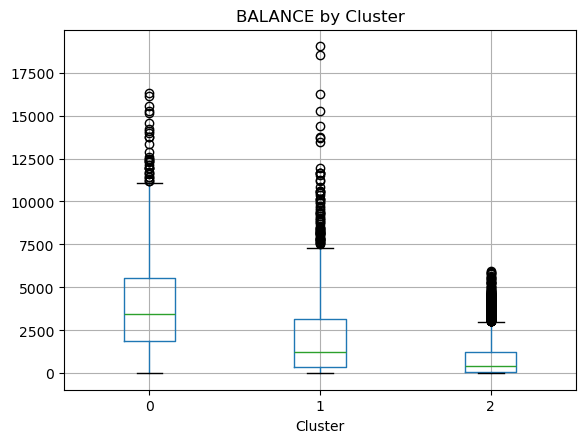

<Figure size 640x480 with 0 Axes>

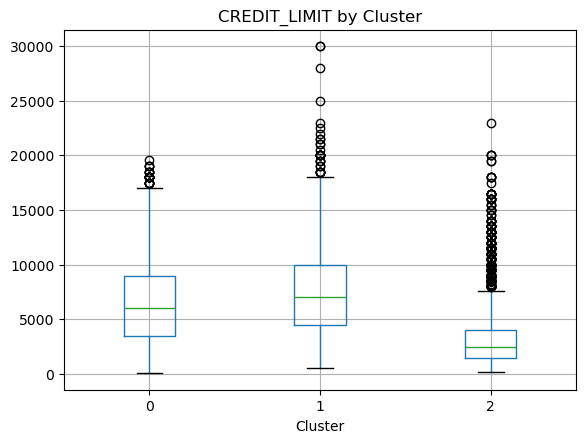

In [22]:
features = [col for col in ['PURCHASES', 'PAYMENTS', 'BALANCE', 'CREDIT_LIMIT'] if col in df.columns]

for col in features:
    plt.figure()
    df.boxplot(column=col, by='Cluster')
    plt.title(f"{col} by Cluster")
    plt.suptitle("")
    plt.show()

## Cluster Summary

The mean values of each feature per cluster provide insight into customer behaviour.

In [23]:
summary = df.groupby('Cluster').mean()
print(summary)

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        3989.326804           0.957980   384.528277        248.718133   
1        2220.003291           0.981477  4268.520980       2717.828543   
2         799.702576           0.835188   505.532394        253.120131   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    135.887632   3869.856855             0.232290   
1                   1551.178267    458.421147             0.949093   
2                    252.733061    329.866776             0.465072   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                          0.110942                          0.144242   
1                          0.668166                        

## Model Evaluation

The silhouette score is used to assess clustering quality.

In [24]:
score = silhouette_score(scaled_data, clusters)
print("Final Silhouette Score:", score)

Final Silhouette Score: 0.25055570796307736


## Conclusion

This tutorial demonstrated how K-Means clustering can be used to segment customers based on financial behaviour.

The results show that:
- Customers can be grouped into distinct behavioural segments
- These clusters can support decision-making in marketing and risk analysis

K-Means is a powerful and interpretable method for exploratory data analysis in real-world datasets.